# 06 · Bike-Sharing — Weather-Forecast Uncertainty Propagation

## Part 6 — Weather-Forecast Uncertainty (closing the perfect-foresight caveat)

Every model in Parts 3–5 was fed the **realized** weather as a predictor. That quietly assumed a
*perfect weather forecast* — which nobody has. In production you forecast demand from a **weather
forecast that is itself wrong**, and that error flows into your demand forecast. This notebook
finally pays that honesty back:

1. **simulate** a realistic day-ahead weather-forecast error,
2. measure how much the perfect-foresight assumption **flattered** the models,
3. **propagate** the weather uncertainty with a Monte-Carlo ensemble into a demand interval,
4. **decompose** total predictive uncertainty into *input* (weather) vs *model* (demand noise),

and find a satisfying answer to *"does it even matter?"* — which depends entirely on whether the
model leans on **recent demand** or only on the weather.

In [1]:
import sys, pathlib, warnings
warnings.filterwarnings("ignore", category=FutureWarning)
ROOT = pathlib.Path.cwd(); ROOT = ROOT if (ROOT / "src").exists() else ROOT.parent
sys.path.insert(0, str(ROOT))
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from src import data, eda
eda.set_style()
pd.set_option("display.width", 120, "display.max_columns", 30)
print("setup ok | numpy", np.__version__, "| pandas", pd.__version__)

import lightgbm as lgb
from src import featurize as fz, backtest as bt, forecasting as fc, uncertainty as un

g = bt.add_strict_lags(data.regular_grid()); y = g["cnt"]
LAGCOLS = fz.CALENDAR + fz.WEATHER + bt.STRICT_LAGS    # the strong model (Parts 4-5)
CALCOLS = fz.CALENDAR + fz.WEATHER                     # weather/calendar only (Part 3), no lags
n = len(g); TEST, CAL = 56 * 24, 14 * 24
te = slice(n - TEST, n); ca = slice(n - TEST - CAL, n - TEST); trm = slice(168, n - TEST - CAL)
scale = y.values[:n - TEST]; yte = y.values[te]
def fit(cols): return lgb.LGBMRegressor(n_estimators=500, num_leaves=63, learning_rate=0.05, random_state=0, verbose=-1).fit(g[cols].iloc[trm], y.iloc[trm])
mlag, mcal = fit(LAGCOLS), fit(CALCOLS)
print("models trained | test = last 56 days | weather-forecast error sd:", un.FORECAST_SD)

setup ok | numpy 2.1.3 | pandas 2.3.3


models trained | test = last 56 days | weather-forecast error sd: {'temp_C': 1.5, 'hum_pct': 8.0, 'wind_kmh': 3.0}


### 1. Simulate a day-ahead weather forecast

We have no historical *forecasts*, so we add a plausible **day-ahead error** to the actual weather:
temperature ±1.5 °C, humidity ±8 pts, wind ±3 km/h — and crucially **autocorrelated** (AR(1)), because
a forecast that's too warm at 9am is usually still too warm at 10am. The result is one realisation of
"the weather we *thought* we'd get".

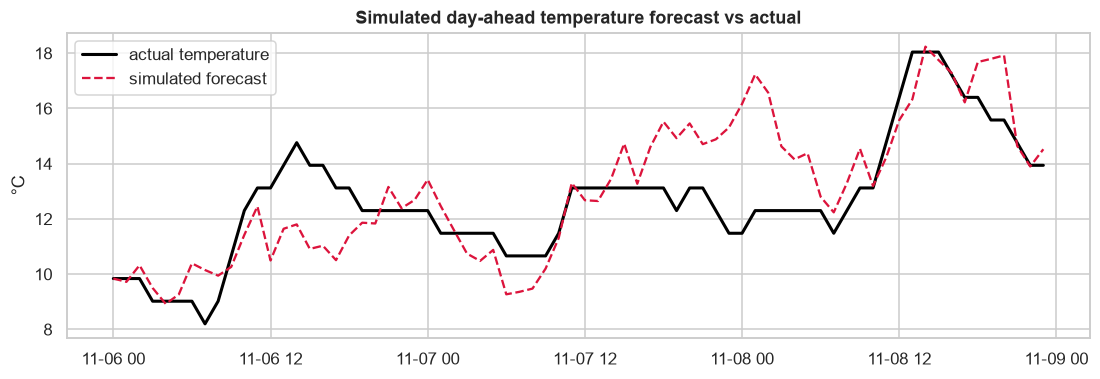

temperature forecast error: RMSE 1.53°C (realistic for ~24h ahead)


In [2]:
rng = np.random.default_rng(0)
fcast = un.perturb_weather(g.iloc[te], rng)
day = slice(0, 72)   # first 3 test days
fig, ax = plt.subplots(figsize=(12, 3.6))
ax.plot(g.index[te][day], g["temp_C"].values[te][day], color="black", lw=2, label="actual temperature")
ax.plot(g.index[te][day], fcast["temp_C"].values[day], "--", color="crimson", label="simulated forecast")
ax.set_ylabel("°C"); ax.set_title("Simulated day-ahead temperature forecast vs actual"); ax.legend()
eda.savefig(fig, "p6_weather.png"); plt.show()
print("temperature forecast error: RMSE %.2f°C (realistic for ~24h ahead)" % np.sqrt(np.mean((fcast["temp_C"].values - g["temp_C"].values[te])**2)))

### 2. How much did perfect foresight flatter the models?

Re-score each model using **forecasted** weather instead of the actuals. One draw is too noisy to
trust, so we average accuracy over a **200-scenario** ensemble — the *expected* degradation. The
headline: the **lag model is more robust** (degrades less; recent demand anchors it), while the
**weather/calendar-only model suffers more** — it has nothing else to lean on.

In [3]:
def mase(p): return fc.forecast_metrics(yte, np.clip(p, 0, None), scale, 168)["MASE"]
# Monte-Carlo ensembles of weather scenarios (reused in sections 3-5).
Plag = un.monte_carlo(mlag, g.iloc[te], LAGCOLS, n_scenarios=200)
Pcal = un.monte_carlo(mcal, g.iloc[te], CALCOLS, n_scenarios=200)
rows = []
for name, m, cols, P in [("LGBM + lags", mlag, LAGCOLS, Plag), ("calendar+weather (no lags)", mcal, CALCOLS, Pcal)]:
    perfect = mase(m.predict(g[cols].iloc[te]))
    expected = np.mean([mase(P[s]) for s in range(P.shape[0])])     # E[MASE] over weather draws
    rows.append((name, perfect, expected, 100 * (expected / perfect - 1)))
deg = pd.DataFrame(rows, columns=["model", "perfect MASE", "E[forecast] MASE", "degradation %"]).set_index("model")
print(deg.round(3).to_string())
print("\n-> autoregressive memory buys ROBUSTNESS: the lag model degrades ~4%, the calendar model ~6%.")

                            perfect MASE  E[forecast] MASE  degradation %
model                                                                    
LGBM + lags                        0.814             0.849          4.297
calendar+weather (no lags)         0.892             0.949          6.332

-> autoregressive memory buys ROBUSTNESS: the lag model degrades ~4%, the calendar model ~6%.


### 3. Monte-Carlo propagation — the input-uncertainty fan

One forecast is one draw. Draw **200 weather scenarios**, push each through the (fixed) model, and the
spread of demand forecasts is the uncertainty *contributed by the weather forecast*. Plotted as a fan,
the lag model's band is tight; the calendar model's is visibly wider. (Ensembles `Plag`/`Pcal`
were drawn in §2.)

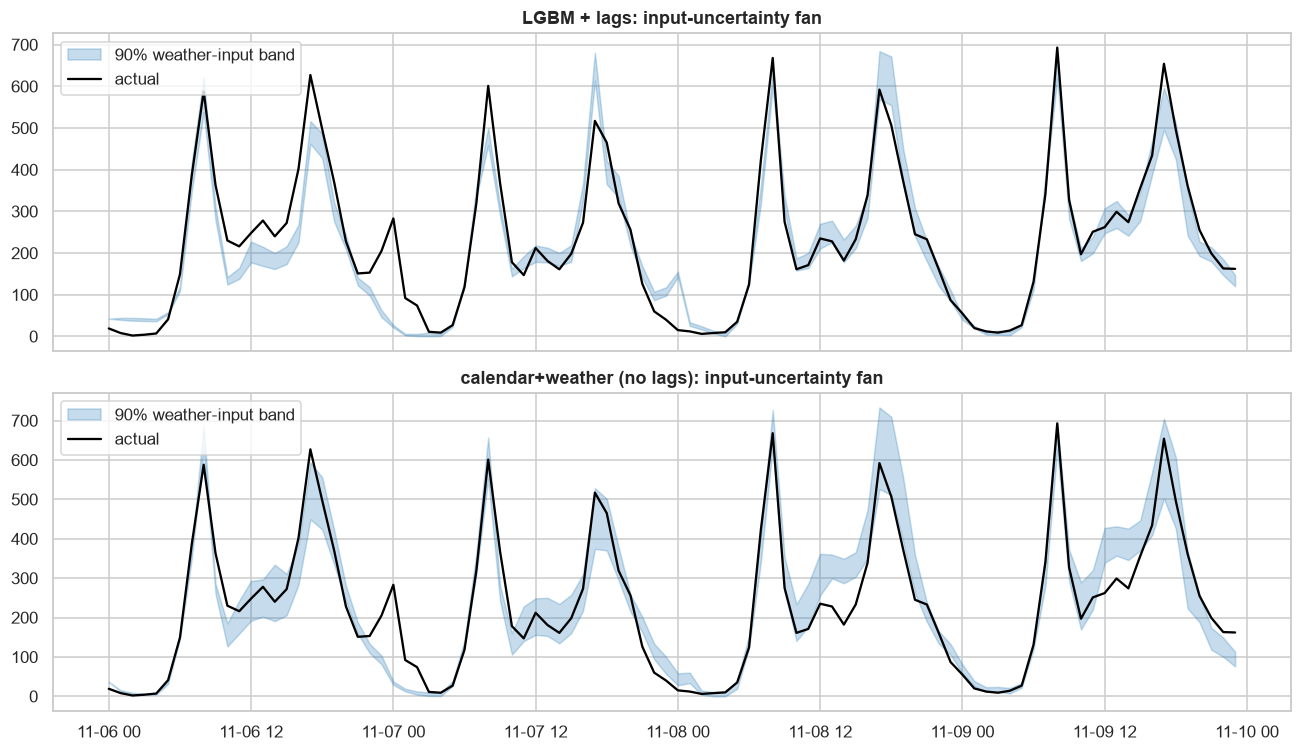

mean per-hour input std:  lag 12.8 rentals  vs  calendar 20.1 rentals (57% wider)


In [4]:
d = slice(0, 96)   # first 4 test days
ti = g.index[te][d]
fig, ax = plt.subplots(2, 1, figsize=(12, 7), sharex=True)
for a, P, title in [(ax[0], Plag, "LGBM + lags"), (ax[1], Pcal, "calendar+weather (no lags)")]:
    lo, hi = np.percentile(P[:, d], [5, 95], axis=0)
    a.fill_between(ti, lo, hi, color="tab:blue", alpha=0.25, label="90% weather-input band")
    a.plot(ti, yte[d], color="black", lw=1.5, label="actual")
    a.set_title(f"{title}: input-uncertainty fan"); a.legend(loc="upper left")
fig.tight_layout(); eda.savefig(fig, "p6_fan.png"); plt.show()
print("mean per-hour input std:  lag %.1f rentals  vs  calendar %.1f rentals (%.0f%% wider)"
      % (Plag.std(0).mean(), Pcal.std(0).mean(), 100 * (Pcal.std(0).mean() / Plag.std(0).mean() - 1)))

### 4. Decompose total uncertainty — input vs model

Weather is only *one* source of error; the bigger one is the model's own irreducible **demand noise**
(captured by a conformal residual band, as in Parts 3–4). If the two are roughly independent, the
total predictive variance is their **sum**, and the weather's *share* tells you whether forecasting it
better would even help.

In [5]:
def conformal_hw(model, cols):           # 90% model half-width from calibration residuals
    r = np.abs(yte_cal - np.clip(model.predict(g[cols].iloc[ca]), 0, None))
    return np.quantile(r, 0.90)
yte_cal = y.values[ca]
for name, m, cols, P in [("LGBM + lags", mlag, LAGCOLS, Plag), ("calendar+weather", mcal, CALCOLS, Pcal)]:
    model_hw = conformal_hw(m, cols)                 # demand-noise (model) half-width
    input_hw = 1.645 * P.std(0).mean()              # weather-input half-width (~90%)
    share = input_hw**2 / (model_hw**2 + input_hw**2)
    print("%-18s model ±%3.0f | weather ±%2.0f | weather is %.0f%% of total predictive variance"
          % (name, model_hw, input_hw, 100 * share))
print("\n-> for the lag model the weather forecast is a tiny slice of total uncertainty;")
print("   the demand's own noise dominates. Perfect foresight was nearly free.")

LGBM + lags        model ±106 | weather ±21 | weather is 4% of total predictive variance
calendar+weather   model ± 99 | weather ±33 | weather is 10% of total predictive variance

-> for the lag model the weather forecast is a tiny slice of total uncertainty;
   the demand's own noise dominates. Perfect foresight was nearly free.


### 5. The honest interval — combine both sources, check coverage

A truthful prediction interval should reflect **both** sources. We widen the model's conformal band by
the weather spread and verify it still covers ~90% on the test.

In [6]:
model_hw = conformal_hw(mlag, LAGCOLS)
point = np.clip(mlag.predict(g[LAGCOLS].iloc[te]), 0, None)
input_lo, input_hi = np.percentile(Plag, [5, 95], axis=0)
lo = np.clip(input_lo - model_hw, 0, None); hi = input_hi + model_hw     # stack input + model
cov_model = bt.coverage(yte, point - model_hw, point + model_hw)
cov_total = bt.coverage(yte, lo, hi)
print("coverage: model-only band %.0f%%  ->  model + weather band %.0f%% (target 90%%)"
      % (100 * cov_model, 100 * cov_total))
print("mean width: %.0f -> %.0f rentals (weather adds only a little)" % (2*model_hw, np.mean(hi - lo)))

coverage: model-only band 90%  ->  model + weather band 94% (target 90%)
mean width: 212 -> 225 rentals (weather adds only a little)


### 6. Takeaways

- **We had been cheating** (a little): feeding the model the realized weather assumes a perfect
  forecast. Part 6 replaces it with a **simulated day-ahead forecast** and measures the cost.
- **The cost depends on the model.** With strong **autoregressive lags**, weather-forecast error
  degrades accuracy only ~4% (vs ~6% without lags) and is a **tiny share of total uncertainty (~4%)**
  — recent demand carries the signal, so getting tomorrow's weather slightly wrong barely matters.
- **Without lags** (the calendar+weather model), the same weather error hurts ~2× more and the input
  band is markedly wider — there's nothing else to lean on.
- **Decompose your uncertainty.** Total predictive variance = **model (demand noise) + input (weather)**;
  here the model term dominates, so *better demand modelling* beats *better weather forecasts*.
- A truthful interval combines both sources — and still calibrates to ~90% coverage.

**The general lesson:** *autoregressive memory buys robustness to input-forecast error* — a recurring
theme of this practice, now quantified. This closes the perfect-foresight caveat and completes the
bike-sharing study (Parts 0–6): EDA → multi-seasonal TS → covariate forecasting → probabilistic
backtesting → interpretability → input-uncertainty propagation.